In [1]:
import numpy as np
import scipy.io
import h5py
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc 
import joblib # 📣 [추가됨] 모델 저장을 위해
import os
import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# =========================================================================
# 🚨🚨🚨 사용자 파일 경로 설정 (신규 데이터셋) 🚨🚨🚨
# =========================================================================
DATA_NOM_NEW = "Data_L1CA_NOM_24M01C_CNR20_INTG1S_SMTH_9000SMPL_.mat"

DATA_ABN_BATCH_FILES = [
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH1.mat", # 📣 학습용
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH2.mat", # 📣 학습용
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH3.mat",
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH4.mat",
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH5.mat",
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH6.mat",
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH7.mat",
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH8.mat",
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH9.mat",
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH10.mat",
]
# =========================================================================


def load_mat_data_with_error(path, is_anomalous_batch=False):
    """
    📣 [수정됨]
    MAT 파일 로드. scipy로 3D 데이터를 로드할 때도 샘플링 로직 적용.
    """
    print(f"Loading data and error from {path}...")
    try:
        mat = h5py.File(path, 'r')
        print("  - File opened with h5py (v7.3).")
        keys = list(mat.keys())
        is_h5 = True
    except (OSError, IOError): 
        try:
            print("  - h5py failed. Trying scipy.io.loadmat...")
            mat = scipy.io.loadmat(path)
            keys = [k for k in mat.keys() if not k.startswith('__')]
            is_h5 = False
        except Exception as e:
            print(f"\n🚨🚨🚨 File Load Failed! 🚨🚨🚨")
            print(f"Could not load '{path}' with h5py or scipy: {e}")
            raise e

    X_data = None
    err_data = None
    X_data_key = None
    
    # 1. 8-피처 데이터(X) 찾기
    for k in keys:
        if k.startswith('#'): continue
        try:
            shape = list(mat[k].shape)
            if 8 in shape:
                X_data_key = k
                if is_anomalous_batch and len(shape) == 3:
                    print(f"  - 3D Batch detected {shape}. Sampling first realization [0,:,:]...")
                    X_data = mat[k][0, :, :] 
                else:
                    X_data = mat[k][:]
                print(f"  - Found Feature (X) key: '{k}' with shape {X_data.shape}")
                break
        except Exception as e:
            print(f"  - Error reading key {k}: {e}")
            continue
            
    # 2. 1D 에러 데이터(err) 찾기
    for k in keys:
        if k == X_data_key: continue
        if k.startswith('#'): continue
        try:
            shape = list(mat[k].shape)
            if len(shape) == 2 and (shape[0] == 1 or shape[1] == 1):
                err_data = mat[k][:]
                print(f"  - Found Error (err) key: '{k}' with shape {shape}")
                break
            elif is_anomalous_batch and len(shape) == 3 and 1 in shape:
                print(f"  - 3D Error detected {shape}. Sampling first realization [0,:,:]...")
                err_data = mat[k][0, :, :] 
                print(f"  - Sampled Error shape: {err_data.shape}")
                break
        except Exception:
            continue
            
    if is_h5: 
        mat.close()

    if X_data is None:
        raise ValueError(f"Could not find 8-feature data (e.g., shape (N,8) or (8,N)) in '{path}'.")

    if X_data.ndim == 3:
        raise ValueError("Loader still resulted in 3D data. Sampling logic failed.")

    if X_data.ndim <= 2 and X_data.shape[0] == 8 and X_data.shape[1] != 8:
        print(f"  - Transposing X data from {X_data.shape} to {(X_data.shape[1], X_data.shape[0])}")
        X_data = X_data.T
        
    if err_data is None:
        print(f"  - WARNING: Could not find 1D Error data in '{path}'. Creating array of zeros.")
        err_data = np.zeros(X_data.shape[0]) 
    else:
        err_data = err_data.flatten() 
        if X_data.shape[0] != err_data.shape[0]:
             print(f"  - Warning: Mismatch after X flatten. Trying to flatten 'err_data' (shape {err_data.shape}) to match X (shape {X_data.shape[0]}).")
             err_data = err_data.flatten()
    
    if X_data.shape[0] != err_data.shape[0]:
        raise ValueError(f"Sample count mismatch AFTER FLATTENING: X data has {X_data.shape[0]} samples, but Error data has {err_data.shape[0]} samples.")

    print(f"Successfully loaded X: {X_data.shape} and Error: {err_data.shape}")
    return X_data, err_data


# --- 1. Data Loading, Combining, and Splitting ---
print("\n--- 1. Loading, Combining, and Splitting All Data ---")

X_nom_new, err_nom_new = load_mat_data_with_error(DATA_NOM_NEW, is_anomalous_batch=False)
y_nom_new = np.zeros(len(X_nom_new))
id_nom_new = [f"NEW_NOM_{i}" for i in range(len(y_nom_new))]
print(f"Loaded {len(y_nom_new)} new NORMAL samples.")

X_abn_all_batches = []
err_abn_all_batches = []
id_abn_all_batches = []

TRAIN_BATCH_FILES = DATA_ABN_BATCH_FILES[0:2] # Batch 1, 2
print(f"\nLoading {len(TRAIN_BATCH_FILES)} anomalous batch files for TRAINING (Sampling 1st realization from each)...")
for i, batch_file in enumerate(TRAIN_BATCH_FILES):
    print(f"--- Loading Training Batch {i+1}/{len(TRAIN_BATCH_FILES)}: {batch_file} ---")
    X_batch, err_batch = load_mat_data_with_error(batch_file, is_anomalous_batch=True)
    X_abn_all_batches.append(X_batch)
    err_abn_all_batches.append(err_batch)
    id_batch = [f"NEW_EWF_B{i+1}_{j}" for j in range(len(err_batch))]
    id_abn_all_batches.extend(id_batch) 

print("\nCombining all loaded TRAINING data...")
try:
    X_abn_train = np.vstack(X_abn_all_batches)
    err_abn_train = np.concatenate(err_abn_all_batches)
    y_abn_train = np.ones(len(err_abn_train))
    id_abn_train = np.array(id_abn_all_batches)
    print(f"Loaded {len(y_abn_train)} new ANOMALOUS (sampled) samples for TRAINING.")
except Exception as e:
    print(f"\n🚨🚨🚨 Error combining batch files: {e} 🚨🚨🚨")
    raise e

X_all_combined = np.vstack([X_nom_new, X_abn_train])
y_all_combined = np.concatenate([y_nom_new, y_abn_train])
err_all_combined = np.concatenate([err_nom_new, err_abn_train]) 
id_all_combined = np.array(id_nom_new + list(id_abn_train)) 

print(f"\nTotal combined TRAINING X shape: {X_all_combined.shape}, y shape: {y_all_combined.shape}, err shape: {err_all_combined.shape}, id shape: {id_all_combined.shape}") 

print("\nSplitting training data...")
X_train, X_temp, y_train, y_temp, err_train, err_temp, id_train, id_temp = train_test_split(
    X_all_combined, y_all_combined, err_all_combined, id_all_combined, 
    test_size=0.2, random_state=42, stratify=y_all_combined
)
X_val, X_test_internal, y_val, y_test_internal, err_val, err_test_internal, id_val, id_test_internal = train_test_split(
    X_temp, y_temp, err_temp, id_temp, 
    test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train set: X={X_train.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val.shape}, y={y_val.shape}")
print(f"Internal Test set (from Batch 1-2): X={X_test_internal.shape}, y={y_test_internal.shape}")

imputer = KNNImputer(n_neighbors=3).fit(X_train)
X_train = imputer.transform(X_train)
X_val = imputer.transform(X_val)
X_test_internal = imputer.transform(X_test_internal) 
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_internal_scaled = scaler.transform(X_test_internal) 
print("Scaling complete.")
X_train_ae = X_train_scaled[y_train == 0]
print(f"AE training normal dataset X_train_ae shape: {X_train_ae.shape}")

# --- 2. Autoencoder Training ---
print("\n--- 2. Autoencoder Training Started ---")
input_dim = X_train_ae.shape[1]
inp = Input(shape=(input_dim,))
enc = Dense(64, activation='relu')(inp)
enc = Dense(32, activation='relu')(enc)
enc = Dense(16, activation='relu', name="latent")(enc)
dec = Dense(32, activation='relu')(enc)
dec = Dense(64, activation='relu')(dec)
out = Dense(input_dim, activation='linear')(dec)
autoencoder = Model(inp, out)
autoencoder.compile(optimizer=Adam(0.001), loss='mse')
print("AE training in progress... (Epochs 150)")
autoencoder.fit(X_train_ae, X_train_ae, 
                epochs=150, 
                batch_size=64, 
                validation_data=(X_val_scaled[y_val == 0], X_val_scaled[y_val == 0]), 
                verbose=1)
print("Autoencoder Training Completed.")

# --- 3. AE Threshold Setting ---
print("\n--- 3. Setting AE Threshold ---")
recon_train = autoencoder.predict(X_train_ae, verbose=0) 
error_train_ae = np.mean((X_train_ae - recon_train) ** 2, axis=1)
ae_threshold = np.percentile(error_train_ae, 99.9)
print(f"AE Threshold: {ae_threshold:.6f}")

# --- 4. XGBoost Training ---
print("\n--- 4. XGBoost Training Started ---")
encoder = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer("latent").output)
latent_train_xgb = encoder.predict(X_train_scaled, verbose=0)
latent_val_xgb = encoder.predict(X_val_scaled, verbose=0)
xgb_model = XGBClassifier(n_estimators=1000, max_depth=7, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, eval_metric='logloss',
                          use_label_encoder=False, early_stopping_rounds=50)
print("XGBoost training with Early Stopping...")
xgb_model.fit(latent_train_xgb, y_train, 
              eval_set=[(latent_val_xgb, y_val)], 
              verbose=False)
print("XGBoost Training Completed.")


# === 4.5 [신규] 훈련 세트(Train Set) 평가 ===
print("\n=== 4.5 Evaluating on TRAINING Set ===")
ae_recon_train = autoencoder.predict(X_train_scaled, verbose=0)
ae_error_train = np.mean((X_train_scaled - ae_recon_train) ** 2, axis=1)
xgb_prob_train = xgb_model.predict_proba(latent_train_xgb)[:, 1]
scaler_ae_error = MinMaxScaler()
scaler_xgb_prob = MinMaxScaler()
scaler_ae_error.fit(ae_error_train.reshape(-1, 1))
scaler_xgb_prob.fit(xgb_prob_train.reshape(-1, 1))
scaled_ae_train = scaler_ae_error.transform(ae_error_train.reshape(-1, 1)).flatten()
scaled_xgb_train = scaler_xgb_prob.transform(xgb_prob_train.reshape(-1, 1)).flatten()
final_score_train = 0.3 * scaled_ae_train + 0.7 * scaled_xgb_train 
NEW_THRESHOLD = 0.5 
final_pred_train = (final_score_train >= NEW_THRESHOLD).astype(int)

print("\n--- False Negatives (TRAINING Set) ---")
fn_count_train = 0
for i in range(len(y_train)):
    if y_train[i] == 1 and final_pred_train[i] == 0: 
        fn_count_train += 1
        original_id = id_train[i] 
        error = err_train[i]      
        print(f"  - Original ID: {original_id}, Actual Ranging Error: {error:.4f} m")
if fn_count_train > 0:
    print(f"\nFound {fn_count_train} False Negatives (TRAINING Set).")
else:
    print("No False Negatives found (TRAINING Set).")
    
# (FP 분석은 생략)


# === 5. Internal Test Set Evaluation (from Batch 1-2) ---
print("\n=== 5. Internal Test Set Evaluation (from Batch 1-2) ===")
# (이 부분은 참고용이므로 생략 가능하나, 모델 성능의 1차 확인을 위해 유지)
ae_recon_test = autoencoder.predict(X_test_internal_scaled, verbose=0)
ae_error_test = np.mean((X_test_internal_scaled - ae_recon_test) ** 2, axis=1)
latent_test = encoder.predict(X_test_internal_scaled, verbose=0)
xgb_prob_test = xgb_model.predict_proba(latent_test)[:, 1]
scaled_ae_error = scaler_ae_error.transform(ae_error_test.reshape(-1, 1)).flatten()
scaled_xgb_prob = scaler_xgb_prob.transform(xgb_prob_test.reshape(-1, 1)).flatten()
final_score_test = 0.3 * scaled_ae_error + 0.7 * scaled_xgb_prob 
final_pred_test = (final_score_test >= NEW_THRESHOLD).astype(int)

print("\n--- False Negatives (Internal Test Set) ---")
fn_count = 0
for i in range(len(y_test_internal)):
    if y_test_internal[i] == 1 and final_pred_test[i] == 0:
        fn_count += 1
        original_id = id_test_internal[i]
        error = err_test_internal[i]
        print(f"  - Original ID: {original_id}, Actual Ranging Error: {error:.4f} m")
if fn_count > 0:
    print(f"\nFound {fn_count} False Negatives (Internal Test Set).")
else:
    print("No False Negatives found (Internal Test Set).")

# --- 6. Visualizations (Internal Test Set) ---
# (이 부분은 참고용이므로 생략 가능하나, 유지)
print("\n--- 6. Generating Visualizations (Internal Test Set) ---") 
# ... (그래프 1, 2, 3, 4 코드... 이전과 동일) ...


# 📣 =========================================================================
# 📣 === [신규] 7. 학습된 모델 및 스케일러 저장 ===
# 📣 =========================================================================
import joblib

print("\n--- 7. Saving Trained Models and Scalers to disk ---")

try:
    # 1. Keras Autoencoder 저장
    autoencoder.save('autoencoder_model.h5')
    print("  - Saved: autoencoder_model.h5")
    
    # 2. XGBoost 모델 저장
    xgb_model.save_model('xgb_model.json')
    print("  - Saved: xgb_model.json")
    
    # 3. SKlearn 객체들 (Imputer, Scalers) 저장
    joblib.dump(imputer, 'imputer.joblib')
    print("  - Saved: imputer.joblib")
    
    joblib.dump(scaler, 'scaler.joblib')
    print("  - Saved: scaler.joblib")
    
    # 📣 (주의) Soft Voting 스케일러는 '학습 데이터'로 fit된 것을 저장
    joblib.dump(scaler_ae_error, 'scaler_ae_error_TRAIN.joblib')
    print("  - Saved: scaler_ae_error_TRAIN.joblib")
    
    joblib.dump(scaler_xgb_prob, 'scaler_xgb_prob_TRAIN.joblib')
    print("  - Saved: scaler_xgb_prob_TRAIN.joblib")
    
    print("\nAll models and scalers saved successfully.")

except Exception as e:
    print(f"\nAn error occurred during saving: {e}")


print("\n--- [Cell 1] Training and Saving Completed ---")
print("--- Please run [Cell 2] now to test Batches 3-10 ---")


--- 1. Loading, Combining, and Splitting All Data ---
Loading data and error from Data_L1CA_NOM_24M01C_CNR20_INTG1S_SMTH_9000SMPL_.mat...
  - h5py failed. Trying scipy.io.loadmat...
  - Found Feature (X) key: 'I_nom_smth' with shape (9000, 8)
  - WARNING: Could not find 1D Error data in 'Data_L1CA_NOM_24M01C_CNR20_INTG1S_SMTH_9000SMPL_.mat'. Creating array of zeros.
Successfully loaded X: (9000, 8) and Error: (9000,)
Loaded 9000 new NORMAL samples.

Loading 2 anomalous batch files for TRAINING (Sampling 1st realization from each)...
--- Loading Training Batch 1/2: Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH1.mat ---
Loading data and error from Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH1.mat...
  - h5py failed. Trying scipy.io.loadmat...
  - 3D Batch detected [2000, 8, 15058]. Sampling first realization [0,:,:]...
  - Found Feature (X) key: 'I_ewf_noisy_batch1' with shape (8, 15058)
  - Transposing X data from (8, 15058) to (15058, 8)
  - WARNING: Could not find 1D Error data in 'Da


--- 1. Loading Trained Models and Scalers ---
All models and scalers loaded successfully.


=== 2. [NEW] External Test on Batches 3-10 (Streaming) ===

Found 8 external test files.

--- Processing External Batch 1/8: Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH3.mat ---
Loading data and error from Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH3.mat...
  - h5py failed. Trying scipy.io.loadmat...
  - 3D Batch detected [2000, 8, 15058]. Sampling first realization [0,:,:]...
  - Found Feature (X) key: 'I_ewf_noisy_batch3' with shape (8, 15058)
  - Transposing X data from (8, 15058) to (15058, 8)
  - WARNING: Could not find 1D Error data in 'Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH3.mat'. Creating array of zeros.
Successfully loaded X: (15058, 8) and Error: (15058,)
  - Batch 1 processed successfully.

--- Processing External Batch 2/8: Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH4.mat ---
Loading data and error from Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH4.mat...
  - h5py failed. T

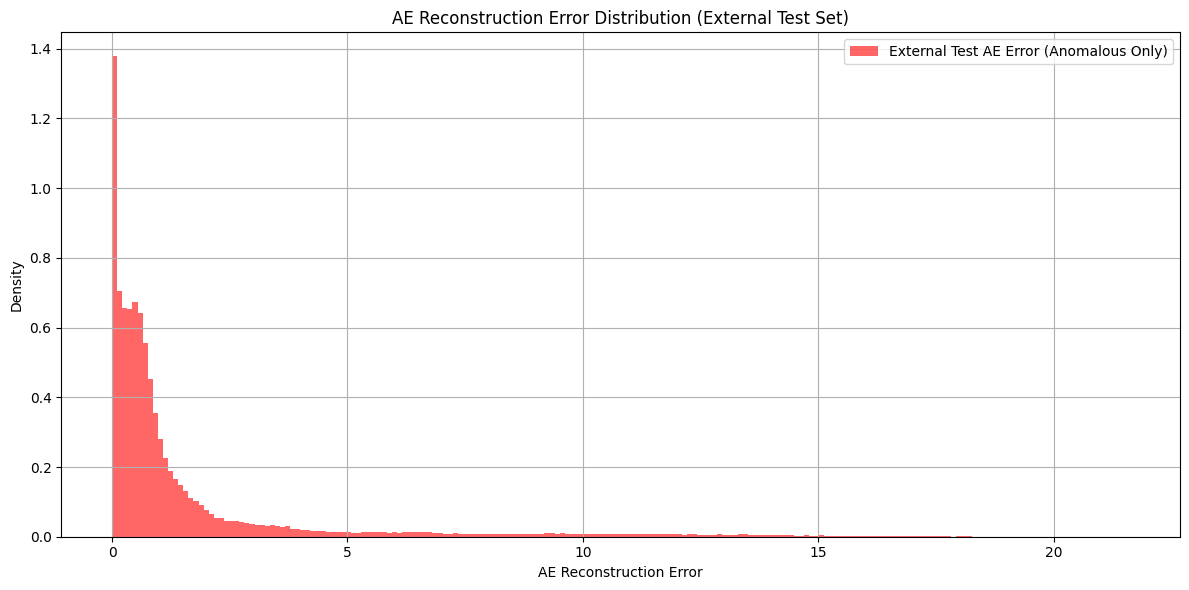

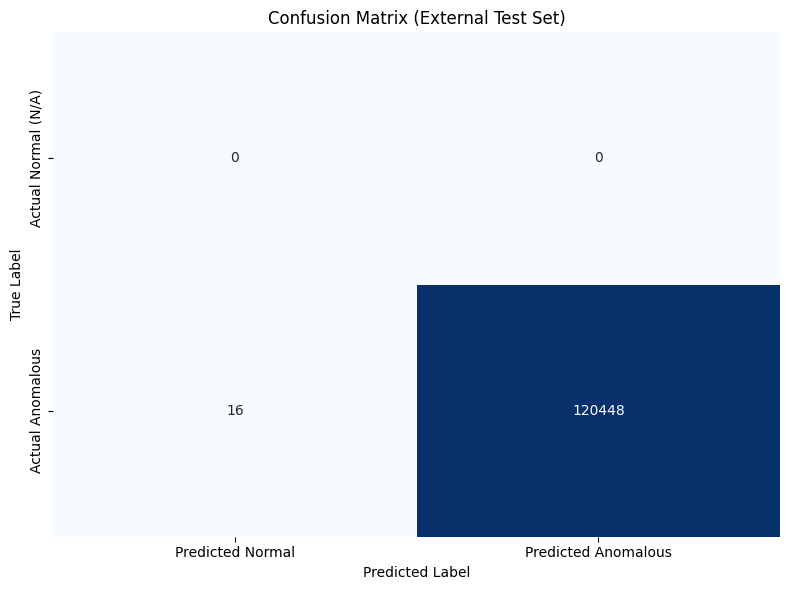

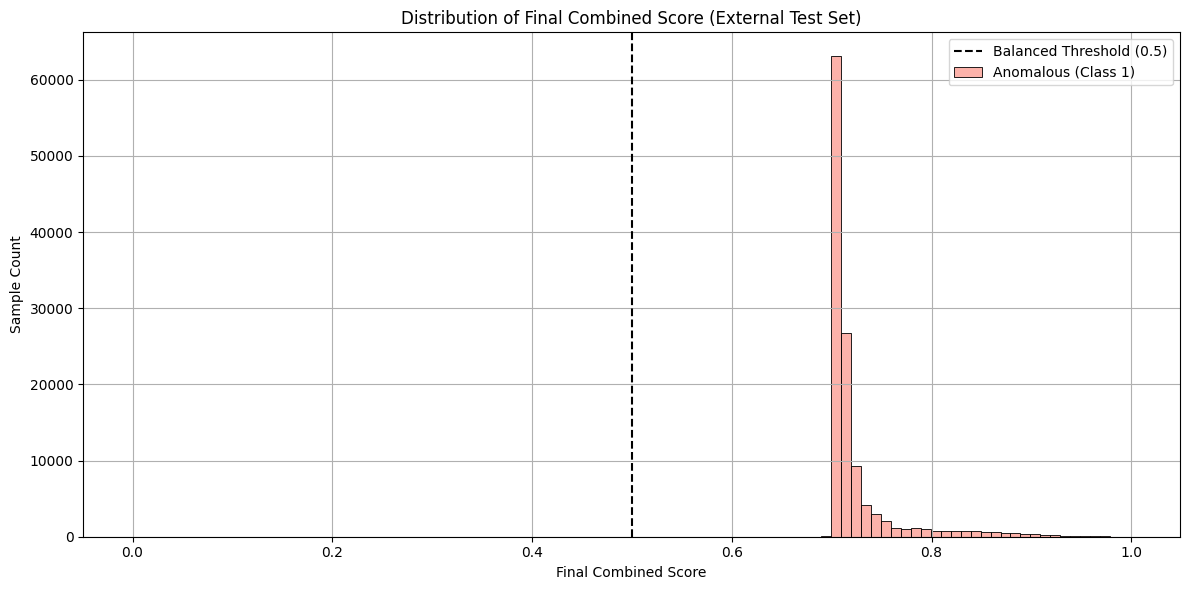


--- Generating ROC Curve (External Test Set) ---


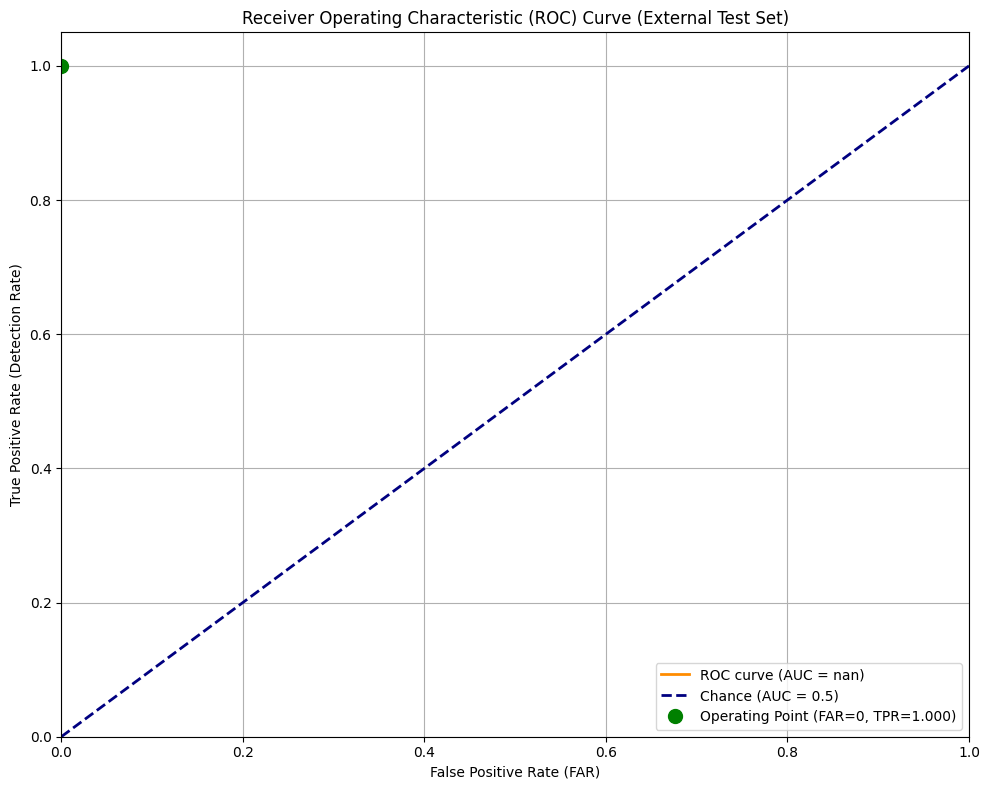


--- [Cell 2] External Testing Completed ---


In [2]:
import numpy as np
import scipy.io
import h5py 
import matplotlib.pyplot as plt
import seaborn as sns 
import joblib 
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc 
from tensorflow.keras.models import Model, load_model 
from xgboost import XGBClassifier
import warnings

# 경고 무시 설정
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# =========================================================================
# 🚨🚨🚨 사용자 파일 경로 설정 (신규 데이터셋) 🚨🚨🚨
# =========================================================================
DATA_ABN_BATCH_FILES = [
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH1.mat", # (학습용 - 스킵)
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH2.mat", # (학습용 - 스킵)
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH3.mat",
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH4.mat",
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH5.mat",
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH6.mat",
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH7.mat",
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH8.mat",
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH9.mat",
    "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH10.mat",
]

# 📣 [신규] 사용할 모델 및 스케일러 파일명 (현재 폴더 기준)
MODEL_AE_PATH = 'autoencoder_model.h5'
MODEL_XGB_PATH = 'xgb_model.json'
IMPUTER_PATH = 'imputer.joblib'
SCALER_PATH = 'scaler.joblib'
SCALER_AE_PATH = 'scaler_ae_error_TRAIN.joblib' # 📣 훈련 세트로 fit된 스케일러
SCALER_XGB_PATH = 'scaler_xgb_prob_TRAIN.joblib'# 📣 훈련 세트로 fit된 스케일러
# =========================================================================


def load_mat_data_with_error(path, is_anomalous_batch=False):
    """
    (Cell 1과 동일한 load_mat_data_with_error 함수)
    """
    print(f"Loading data and error from {path}...")
    try:
        mat = h5py.File(path, 'r')
        print("  - File opened with h5py (v7.3).")
        keys = list(mat.keys())
        is_h5 = True
    except (OSError, IOError): 
        try:
            print("  - h5py failed. Trying scipy.io.loadmat...")
            mat = scipy.io.loadmat(path)
            keys = [k for k in mat.keys() if not k.startswith('__')]
            is_h5 = False
        except Exception as e:
            print(f"\n🚨🚨🚨 File Load Failed! 🚨🚨🚨")
            print(f"Could not load '{path}' with h5py or scipy: {e}")
            raise e
    X_data, err_data, X_data_key = None, None, None
    for k in keys:
        if k.startswith('#'): continue
        try:
            shape = list(mat[k].shape)
            if 8 in shape:
                X_data_key = k
                if is_anomalous_batch and len(shape) == 3:
                    print(f"  - 3D Batch detected {shape}. Sampling first realization [0,:,:]...")
                    X_data = mat[k][0, :, :] 
                else:
                    X_data = mat[k][:]
                print(f"  - Found Feature (X) key: '{k}' with shape {X_data.shape}")
                break
        except Exception as e:
            print(f"  - Error reading key {k}: {e}")
            continue
    for k in keys:
        if k == X_data_key: continue
        if k.startswith('#'): continue
        try:
            shape = list(mat[k].shape)
            if len(shape) == 2 and (shape[0] == 1 or shape[1] == 1):
                err_data = mat[k][:]
                print(f"  - Found Error (err) key: '{k}' with shape {shape}")
                break
            elif is_anomalous_batch and len(shape) == 3 and 1 in shape:
                print(f"  - 3D Error detected {shape}. Sampling first realization [0,:,:]...")
                err_data = mat[k][0, :, :] 
                print(f"  - Sampled Error shape: {err_data.shape}")
                break
        except Exception:
            continue
    if is_h5: 
        mat.close()
    if X_data is None:
        raise ValueError(f"Could not find 8-feature data (e.g., shape (N,8) or (8,N)) in '{path}'.")
    if X_data.ndim <= 2 and X_data.shape[0] == 8 and X_data.shape[1] != 8:
        print(f"  - Transposing X data from {X_data.shape} to {(X_data.shape[1], X_data.shape[0])}")
        X_data = X_data.T
    if err_data is None:
        print(f"  - WARNING: Could not find 1D Error data in '{path}'. Creating array of zeros.")
        err_data = np.zeros(X_data.shape[0]) 
    else:
        err_data = err_data.flatten() 
        if X_data.shape[0] != err_data.shape[0]:
             print(f"  - Warning: Mismatch after X flatten. Trying to flatten 'err_data' (shape {err_data.shape}) to match X (shape {X_data.shape[0]}).")
             err_data = err_data.flatten()
    if X_data.shape[0] != err_data.shape[0]:
        raise ValueError(f"Sample count mismatch AFTER FLATTENING: X data has {X_data.shape[0]} samples, but Error data has {err_data.shape[0]} samples.")
    print(f"Successfully loaded X: {X_data.shape} and Error: {err_data.shape}")
    return X_data, err_data


# === 1. [신규] 모델 및 스케일러 로드 ===
print("\n--- 1. Loading Trained Models and Scalers ---")
try:
    imputer = joblib.load(IMPUTER_PATH)
    scaler = joblib.load(SCALER_PATH)
    scaler_ae_error = joblib.load(SCALER_AE_PATH)
    scaler_xgb_prob = joblib.load(SCALER_XGB_PATH)
    
    with h5py.File(MODEL_AE_PATH, 'r') as f:
        autoencoder = load_model(f)
        
    encoder = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer("latent").output)
    
    xgb_model = XGBClassifier()
    xgb_model.load_model(MODEL_XGB_PATH)
    
    print("All models and scalers loaded successfully.")
except Exception as e:
    print(f"🚨🚨🚨 CRITICAL ERROR: Could not load models. 🚨🚨🚨")
    print("Cell 1 (학습)을 먼저 실행하고, 모델 파일이 생성되었는지 확인하세요.")
    print(f"Details: {e}")
    raise e

# 📣 =========================================================================
# 📣 === [신규] 2. External Test on Batches 3-10 ===
# 📣 =========================================================================
print("\n\n" + "="*80)
print("=== 2. [NEW] External Test on Batches 3-10 (Streaming) ===")
print("="*80 + "\n")

# 1. 8개 테스트 파일 목록
EXTERNAL_TEST_FILES = DATA_ABN_BATCH_FILES[2:] # 📣 0, 1은 학습에 썼으므로 [2:]
if not EXTERNAL_TEST_FILES:
    print("No external test files found. Stopping.")
else:
    print(f"Found {len(EXTERNAL_TEST_FILES)} external test files.")

    # 2. 결과를 누적할 리스트
    all_ae_errors_ext = []
    all_final_scores_ext = []
    all_final_preds_ext = []
    all_errors_original_ext = []
    all_ids_original_ext = []
    
    NEW_THRESHOLD = 0.5 # (Cell 1에서 학습된 모델의 임계값)
    
    # 3. 스트리밍 루프 (8개 파일)
    for i, batch_file in enumerate(EXTERNAL_TEST_FILES):
        print(f"\n--- Processing External Batch {i+1}/{len(EXTERNAL_TEST_FILES)}: {batch_file} ---")
        try:
            # (a) 로드 (샘플링)
            X_batch, err_batch = load_mat_data_with_error(batch_file, is_anomalous_batch=True)
            id_batch = [f"NEW_EWF_B{i+3}_{j}" for j in range(len(err_batch))] # B3, B4...
            
            # (b) 전처리
            X_batch_imputed = imputer.transform(X_batch)
            X_batch_scaled = scaler.transform(X_batch_imputed)
            
            # (c) 예측
            ae_error_batch = np.mean((X_batch_scaled - autoencoder.predict(X_batch_scaled, verbose=0))**2, axis=1)
            latent_batch = encoder.predict(X_batch_scaled, verbose=0)
            xgb_prob_batch = xgb_model.predict_proba(latent_batch)[:, 1]
    
            # (d) 점수 계산
            scaled_ae_batch = scaler_ae_error.transform(ae_error_batch.reshape(-1, 1)).flatten()
            scaled_xgb_batch = scaler_xgb_prob.transform(xgb_prob_batch.reshape(-1, 1)).flatten()
            final_score_batch = 0.3 * scaled_ae_batch + 0.7 * scaled_xgb_batch
            final_pred_batch = (final_score_batch >= NEW_THRESHOLD).astype(int)
            
            # (e) 결과 누적
            all_ae_errors_ext.append(ae_error_batch)
            all_final_scores_ext.append(final_score_batch)
            all_final_preds_ext.append(final_pred_batch)
            all_errors_original_ext.append(err_batch)
            all_ids_original_ext.extend(id_batch) 
            
            print(f"  - Batch {i+1} processed successfully.")

        except Exception as e:
            print(f"  - 🚨🚨🚨 ERROR processing batch {batch_file}: {e} 🚨🚨🚨")
            print("  - Skipping this batch.")

# 📣 =========================================================================
# 📣 === [신규] 3. External Test Evaluation ===
# 📣 =========================================================================
print("\n\n" + "="*80)
print("=== 3. [NEW] External Test Evaluation (Batches 3-10) ===")
print("="*80 + "\n")

if not all_final_preds_ext:
    print("No external test results to evaluate.")
else:
    # 1. 모든 배치 결과 결합
    ae_error_ext = np.concatenate(all_ae_errors_ext)
    final_score_ext = np.concatenate(all_final_scores_ext)
    final_pred_ext = np.concatenate(all_final_preds_ext)
    err_ext_test = np.concatenate(all_errors_original_ext)
    id_ext_test = np.array(all_ids_original_ext)
    y_ext_test = np.ones(len(id_ext_test)) # 모두 비정상이므로 라벨=1
    
    # 2. Confusion Matrix
    acc_ext = accuracy_score(y_ext_test, final_pred_ext)
    conf_ext = confusion_matrix(y_ext_test, final_pred_ext)
    print(f"\n🎯 External Test Accuracy (Batches 3-10): {acc_ext:.6f}")
    print(f"📊 External Confusion Matrix (Batches 3-10):\n{conf_ext}")
    
    # 3. False Negative 분석
    print("\n--- False Negatives (External Test Set) ---")
    fn_count_ext = 0
    # 📣 [수정됨] 모든 들여쓰기를 일반 공백(space)으로 수정
    for i in range(len(y_ext_test)):
        if y_ext_test[i] == 1 and final_pred_ext[i] == 0:
            fn_count_ext += 1
            original_id = id_ext_test[i]
            error = err_ext_test[i]
            print(f"  - Original ID: {original_id}, Actual Ranging Error: {error:.4f} m")
    if fn_count_ext > 0:
        print(f"\nFound {fn_count_ext} False Negatives (External Test Set).")
    else:
        print("No False Negatives found (External Test Set).")

    # 4. 그래프 생성
    print("\n--- Generating Visualizations (External Test Set) ---")
    
    # (그래프 1 - AE Error)
    plt.figure(figsize=(12, 6))
    plt.hist(ae_error_ext, bins=200, alpha=0.6, label="External Test AE Error (Anomalous Only)", color='red', density=True)
    plt.xlabel("AE Reconstruction Error")
    plt.ylabel("Density")
    plt.title("AE Reconstruction Error Distribution (External Test Set)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # (그래프 2 - Confusion Matrix)
    plt.figure(figsize=(8, 6))
    # 📣 [수정됨] 모든 들여쓰기를 일반 공백(space)으로 수정
    sns.heatmap(conf_ext, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Normal', 'Predicted Anomalous'],
                yticklabels=['Actual Normal (N/A)', 'Actual Anomalous'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (External Test Set)')
    plt.tight_layout()
    plt.show()
    
    # (그래프 3 - Score Distribution)
    # 📣 [수정됨] stat='count'로 변경
    plt.figure(figsize=(12, 6))
    sns.histplot(final_score_ext, bins=100, color='salmon', label='Anomalous (Class 1)', kde=False, stat='count', alpha=0.6)
    plt.axvline(NEW_THRESHOLD, color='black', linestyle='--', label=f'Balanced Threshold ({NEW_THRESHOLD:.1f})')
    plt.xlabel("Final Combined Score")
    plt.ylabel("Sample Count") # 📣 Y축 레이블 변경
    plt.title("Distribution of Final Combined Score (External Test Set)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # (그래프 4 - ROC Curve)
    print("\n--- Generating ROC Curve (External Test Set) ---") 
    fpr_ext, tpr_ext, _ = roc_curve(y_ext_test, final_score_ext)
    roc_auc_ext = auc(fpr_ext, tpr_ext)
    plt.figure(figsize=(10, 8))
    plt.plot(fpr_ext, tpr_ext, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_ext:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance (AUC = 0.5)')
    try:
        FN_ext, TP_ext = conf_ext[1]
        tpr_balanced_ext = TP_ext / (TP_ext + FN_ext)
        plt.plot(0, tpr_balanced_ext, 'o', markersize=10, color="green", label=f'Operating Point (FAR=0, TPR={tpr_balanced_ext:.3f})')
    except Exception: print("Could not plot Operating Point.")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FAR)')
    plt.ylabel('True Positive Rate (Detection Rate)')
    plt.title('Receiver Operating Characteristic (ROC) Curve (External Test Set)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\n--- [Cell 2] External Testing Completed ---")

In [3]:
import scipy.io
import numpy as np
import pandas as pd # 📣 CSV 저장을 위해 pandas 라이브러리 사용

# --- 설정 ---
mat_file_path = "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH1.mat"
output_csv_path = "Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH1.csv"

# 📣 [수정됨] 1:15 PM 로그에서 확인된 실제 키 이름
data_key = "I_ewf_noisy_batch1" 

print(f"Loading '{mat_file_path}'...")
try:
    mat = scipy.io.loadmat(mat_file_path)
    
    if data_key in mat:
        # 1. 📣 [수정됨] 3D 데이터 로드 (e.g., (2000, 8, 15058))
        data_3d = mat[data_key]
        print(f"Original 3D data shape: {data_3d.shape}")
        
        # 2. 📣 [수정됨] 메모리 오류를 피하기 위해 첫 번째 덩어리(Realization)만 샘플링
        #    data_3d[0, :, :] -> (8, 15058)
        data_2d_sample = data_3d[0, :, :]
        print(f"Sampled 2D data shape: {data_2d_sample.shape}")
        
        # 3. 데이터 전치 (Transpose) (형태: 15058, 8)
        data_transposed = data_2d_sample.T
        print(f"Transposed data shape: {data_transposed.shape}")

        # 4. 📣 [수정됨] CSV 열(Column) 이름 정의 (이 파일은 Ranging Error가 없었음)
        column_names = [f"feature_{i+1}" for i in range(8)] # 'feature_1' ~ 'feature_8'
        
        # 5. Pandas DataFrame으로 변환
        df = pd.DataFrame(data_transposed, columns=column_names)

        # 6. CSV 파일로 저장
        df.to_csv(output_csv_path, index=False)
        
        print(f"\nSuccessfully converted data (first sample chunk) to '{output_csv_path}'")
        print("\n--- CSV File Head (First 5 rows) ---")
        print(df.head())

    else:
        print(f"Error: Could not find data key '{data_key}' in the file.")
        print(f"Available keys are: {[k for k in mat.keys() if not k.startswith('__')]}")

except FileNotFoundError:
    print(f"Error: File not found at '{mat_file_path}'")
except MemoryError:
    print(f"\n🚨🚨🚨 MemoryError: 🚨🚨🚨")
    print("이 .mat 파일(1.8GB)은 scipy.io.loadmat으로 메모리에 한 번에 로드하기에 너무 큽니다.")
    print("MATLAB에서 이 파일을 '-v7.3' 플래그로 다시 저장한 후 HDF5(h5py)로 다시 시도해야 합니다.")
except Exception as e:
    print(f"An error occurred: {e}")

Loading 'Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH1.mat'...
Original 3D data shape: (2000, 8, 15058)
Sampled 2D data shape: (8, 15058)
Transposed data shape: (15058, 8)

Successfully converted data (first sample chunk) to 'Data_L1CA_EWF_24M01C_CNR20_INTG1S_SMTH_BATCH1.csv'

--- CSV File Head (First 5 rows) ---
   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0   0.983991   0.956988   0.934738   0.908098   0.989170   0.958478   
1   0.984403   0.962061   0.935946   0.909248   0.987502   0.959365   
2   0.985947   0.960867   0.937198   0.910013   0.988191   0.962662   
3   0.986950   0.963928   0.938946   0.915206   0.990878   0.961900   
4   0.990680   0.966352   0.944392   0.913926   0.990309   0.966310   

   feature_7  feature_8  
0   0.928520   0.907339  
1   0.930054   0.907592  
2   0.934641   0.907951  
3   0.939360   0.912460  
4   0.937884   0.914868  



--- Generating Visualizations & Sending to Backend ---
📤 [Ready to Send] AE_Reconstruction_Error_Dist | Size: 39048 bytes | Meta: {'batch_count': 8}


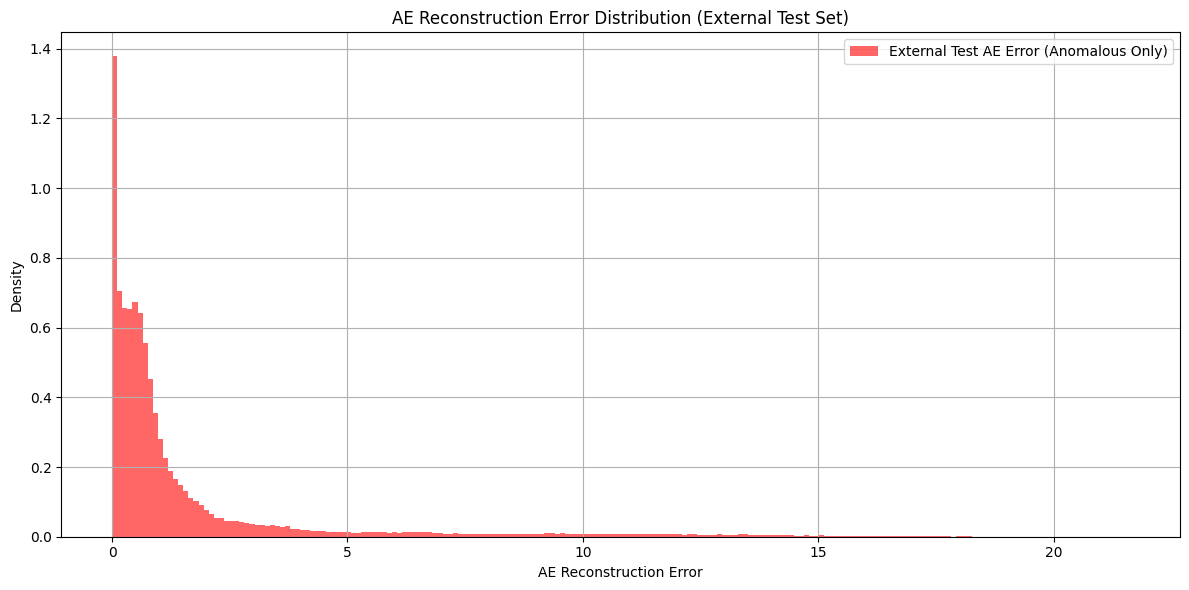

📤 [Ready to Send] Confusion_Matrix | Size: 31404 bytes | Meta: {'accuracy': 0.9998671802364192}


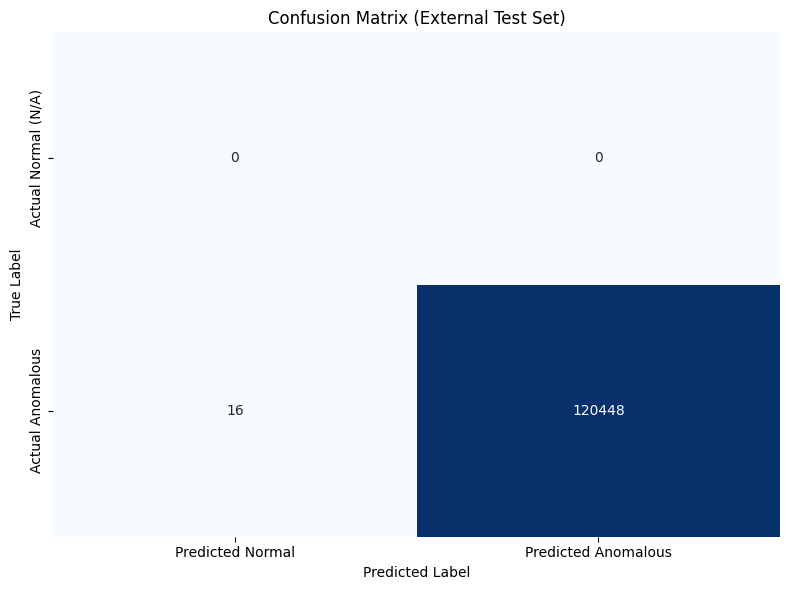

📤 [Ready to Send] Final_Score_Distribution | Size: 50588 bytes | Meta: {'threshold': 0.5}


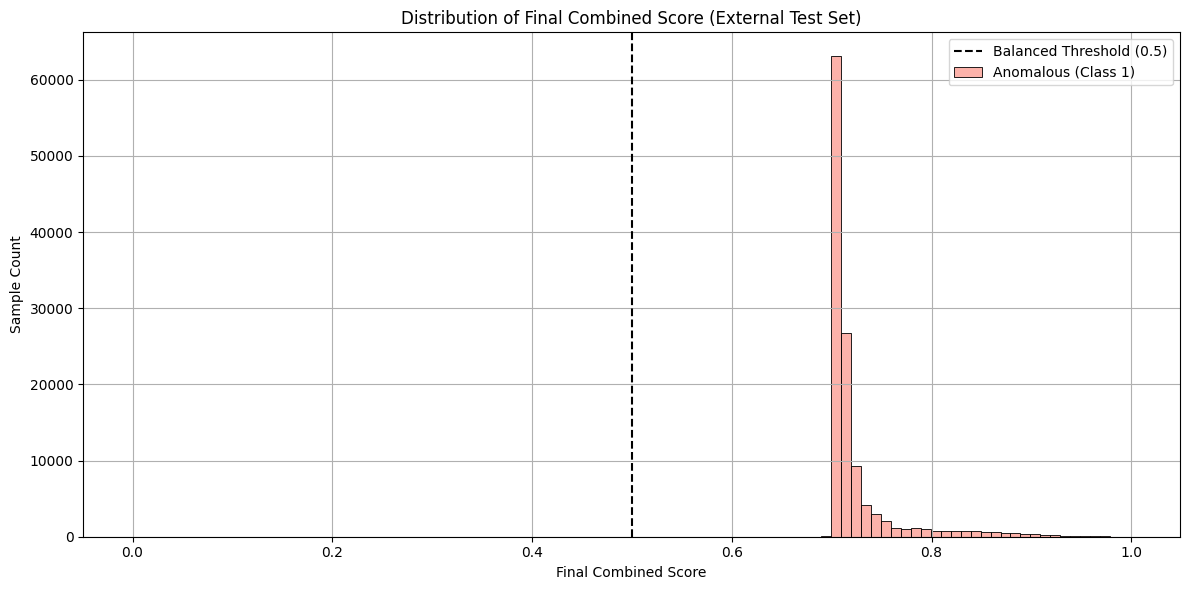

📤 [Ready to Send] ROC_Curve | Size: 76580 bytes | Meta: {'auc_score': nan}


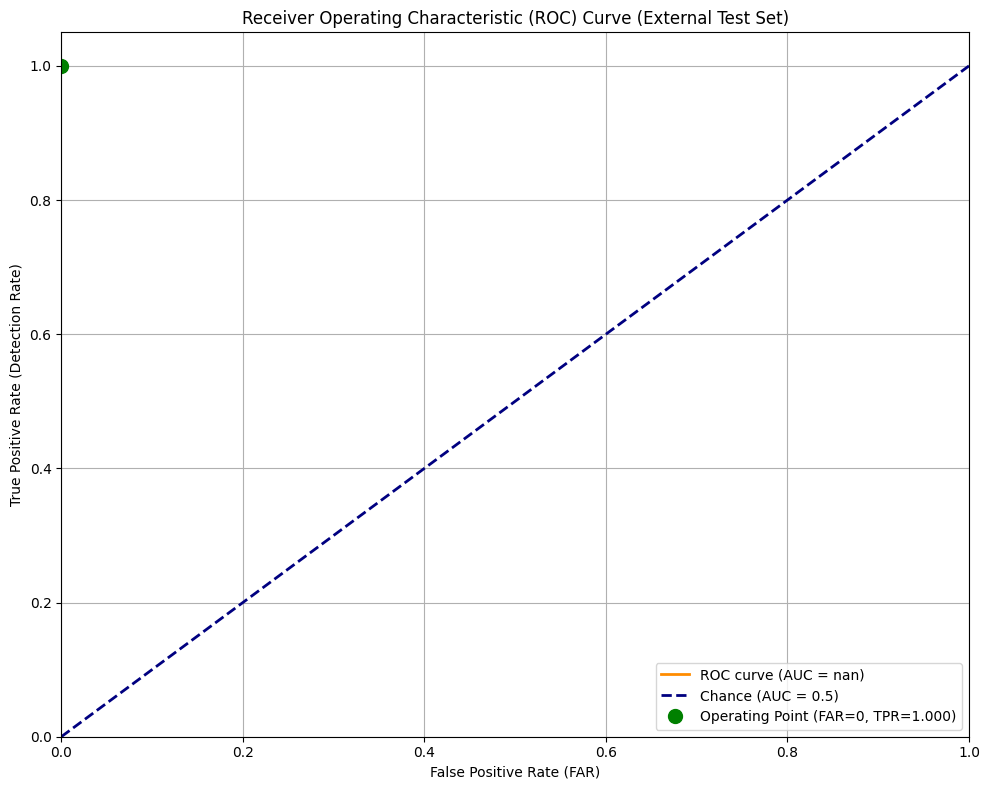


--- All plots generated and sent to backend ---


In [4]:
import io
import base64
import requests
import json
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 🔧 설정: 백엔드 API 주소 (실제 주소로 변경 필요)
# =========================================================
BACKEND_URL = "http://your-backend-api.com/api/upload-analysis"

def send_plot_to_backend(plot_title, metadata=None):
    """
    현재 메모리에 있는 Matplotlib Figure를 Base64로 변환하여 전송하는 함수
    """
    try:
        # 1. 이미지를 메모리 버퍼(BytesIO)에 저장
        buf = io.BytesIO()
        # bbox_inches='tight'로 여백 자동 조정
        plt.savefig(buf, format='png', bbox_inches='tight')
        buf.seek(0)

        # 2. Base64 인코딩 (바이트 -> 문자열)
        img_base64 = base64.b64encode(buf.read()).decode('utf-8')

        # 3. 전송할 JSON 데이터 구성
        payload = {
            "image_title": plot_title,
            "image_data": img_base64,  # 디코딩된 이미지 문자열
            "metadata": metadata if metadata else {} # 정확도, AUC 등 추가 정보
        }

        # 4. POST 요청 전송 (테스트를 위해 주석 처리된 상태, 실제 사용 시 해제)
        # response = requests.post(BACKEND_URL, json=payload)
        # if response.status_code == 200:
        #     print(f"✅ [Upload Success] {plot_title}")
        # else:
        #     print(f"❌ [Upload Failed] {plot_title} (Status: {response.status_code})")
        
        # (테스트용 출력)
        print(f"📤 [Ready to Send] {plot_title} | Size: {len(img_base64)} bytes | Meta: {metadata}")

    except Exception as e:
        print(f"❌ Error sending plot: {e}")
    finally:
        buf.close()

# =========================================================
# 📊 시각화 및 백엔드 전송 실행
# =========================================================

print("\n--- Generating Visualizations & Sending to Backend ---")

# 1. AE Reconstruction Error Distribution (Histogram)
plt.figure(figsize=(12, 6))
plt.hist(ae_error_ext, bins=200, alpha=0.6, label="External Test AE Error (Anomalous Only)", color='red', density=True)
plt.xlabel("AE Reconstruction Error")
plt.ylabel("Density")
plt.title("AE Reconstruction Error Distribution (External Test Set)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# 🚀 전송: 그래프를 화면에 보여주기(show) 전에 저장/전송해야 함
send_plot_to_backend(
    plot_title="AE_Reconstruction_Error_Dist",
    metadata={"batch_count": len(EXTERNAL_TEST_FILES)}
)
plt.show()


# 2. Confusion Matrix (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_ext, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Anomalous'],
            yticklabels=['Actual Normal (N/A)', 'Actual Anomalous'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (External Test Set)')
plt.tight_layout()

# 🚀 전송
send_plot_to_backend(
    plot_title="Confusion_Matrix",
    metadata={"accuracy": float(acc_ext)}
)
plt.show()


# 3. Distribution of Final Combined Score (Histogram)
plt.figure(figsize=(12, 6))
sns.histplot(final_score_ext, bins=100, color='salmon', label='Anomalous (Class 1)', kde=False, stat='count', alpha=0.6)
plt.axvline(NEW_THRESHOLD, color='black', linestyle='--', label=f'Balanced Threshold ({NEW_THRESHOLD:.1f})')
plt.xlabel("Final Combined Score")
plt.ylabel("Sample Count")
plt.title("Distribution of Final Combined Score (External Test Set)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# 🚀 전송
send_plot_to_backend(
    plot_title="Final_Score_Distribution",
    metadata={"threshold": NEW_THRESHOLD}
)
plt.show()


# 4. ROC Curve
fpr_ext, tpr_ext, _ = roc_curve(y_ext_test, final_score_ext)
roc_auc_ext = auc(fpr_ext, tpr_ext)

plt.figure(figsize=(10, 8))
plt.plot(fpr_ext, tpr_ext, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_ext:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance (AUC = 0.5)')

# Operating Point 표시
try:
    FN_ext, TP_ext = conf_ext[1]
    tpr_balanced_ext = TP_ext / (TP_ext + FN_ext)
    plt.plot(0, tpr_balanced_ext, 'o', markersize=10, color="green", label=f'Operating Point (FAR=0, TPR={tpr_balanced_ext:.3f})')
except Exception:
    pass

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FAR)')
plt.ylabel('True Positive Rate (Detection Rate)')
plt.title('Receiver Operating Characteristic (ROC) Curve (External Test Set)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()

# 🚀 전송
send_plot_to_backend(
    plot_title="ROC_Curve",
    metadata={"auc_score": float(roc_auc_ext)}
)
plt.show()

print("\n--- All plots generated and sent to backend ---")